# Preprocesamiento para regresion: prediccion de estres en jugadores

Este notebook prepara un dataset listo para modelar el **nivel de estres (`stress_level`)** de un jugador en funcion de sus habitos de gaming.

---

## 1) Problema, objetivos y KPIs

### Problema
Desarrollar una solucion de analitica predictiva que estime el nivel de estres de jugadores a partir de variables de comportamiento de juego, estilo de vida y contexto digital.

### Objetivo general (SMART)
Construir en una semana un dataset limpio, transformado y validado para entrenar un modelo de **regresion** que prediga `stress_level`, logrando un baseline reproducible y trazable.

### Objetivos especificos (SMART)
1. Integrar y limpiar el dataset crudo de forma reproducible en una sola ejecucion del notebook.
2. Alcanzar al menos un **95% de completitud** en variables de entrada tras imputacion.
3. Dejar listas variables numericas escaladas y categoricas codificadas para regresion.
4. Exportar el dataset final a `Dataset/data_lista_para_regresion.csv`.

### Alcance
- Incluye: carga, auditoria de calidad, EDA, limpieza, imputacion, codificacion, escalado y particion train/test.
- Excluye: entrenamiento de modelos avanzados, tuning y despliegue.

### KPIs del proyecto
- **KPI-1 (Calidad):** porcentaje de nulos final en features <= 1%.
- **KPI-2 (Cobertura):** 100% de columnas justificadas (se usan o se excluyen con razon).
- **KPI-3 (Reproducibilidad):** ejecucion end-to-end sin pasos manuales.
- **KPI-4 (Modelado):** disponibilidad de `X_train`, `X_test`, `y_train`, `y_test` y dataset final exportado.

## 2) Antecedentes y fuentes

### Contexto
La literatura reciente sobre salud mental digital muestra asociaciones entre intensidad de juego, calidad de sueno, aislamiento social y estres percibido. En este proyecto se operacionaliza ese marco con variables observables del dataset.

### Fuente principal de datos
- Archivo: `RAW/gaming_mental_health_10M_40features.csv.gz`
- Tamano: gran escala (millones de registros) con variables demograficas, habitos de juego y metricas psicologicas.

### Integracion de fuentes
Para este notebook se usa la fuente principal estructurada. La integracion conceptual proviene de evidencia de salud digital y comportamiento gamer para justificar seleccion de variables y decisiones de limpieza.

## 3) Requisitos del proyecto

### Requisitos funcionales
1. Cargar dataset comprimido `.csv.gz` desde `RAW/`.
2. Detectar y reportar nulos, duplicados y tipos de datos.
3. Ejecutar EDA con visualizaciones del target y relaciones clave.
4. Aplicar limpieza e imputacion con criterios reproducibles.
5. Codificar variables categoricas y escalar numericas.
6. Separar en train/test para regresion.
7. Exportar salida final en `Dataset/data_lista_para_regresion.csv`.

### Requisitos no funcionales
- **Reproducibilidad:** semilla fija (`random_state`).
- **Trazabilidad:** impresion de metricas de calidad antes y despues.
- **Mantenibilidad:** pipeline legible en celdas secuenciales.
- **Eficiencia:** opcion para limitar filas si el hardware no permite cargar todo el dataset.

## 4) Dataset pertinente, suficiente y justificado

El dataset es pertinente porque contiene:
- Variable objetivo directa: `stress_level`.
- Variables conductuales de gaming: `daily_gaming_hours`, `weekly_sessions`, `night_gaming_ratio`, etc.
- Variables de estilo de vida y salud: `sleep_hours`, `exercise_hours`, `bmi`, `eye_strain_score`.
- Variables psicosociales: `loneliness_score`, `social_interaction_score`, `relationship_satisfaction`.

La escala del dataset permite entrenar modelos de regresion robustos y generalizables, incluso trabajando con una muestra amplia para optimizar recursos de computo.

## 5) Metodologia (fases, tareas y plazos)

| Fase | Tareas | Entregable | Plazo sugerido |
|---|---|---|---|
| F1. Comprension | Definir problema, objetivo y KPIs | Alcance y criterios de exito | Dia 1 |
| F2. Ingesta y auditoria | Carga, tipos, nulos, duplicados | Reporte de calidad inicial | Dia 1 |
| F3. EDA | Distribuciones, relaciones con target, correlaciones | Hallazgos exploratorios | Dia 2 |
| F4. Preprocesamiento | Imputacion, outliers, encoding, escalado | Matriz lista para regresion | Dia 3 |
| F5. Validacion de calidad | Verificar nulos, coherencia y formas train/test | Checklist de calidad final | Dia 3 |
| F6. Publicacion de dataset | Exportar `data_lista_para_regresion.csv` | Dataset final versionado | Dia 3 |

In [ ]:
# 0) Librerias y configuracion
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
N_ROWS = 1_000_000  # Usa None para intentar cargar todo el dataset

ROOT = Path.cwd()
RAW_PATH = ROOT / "RAW" / "gaming_mental_health_10M_40features.csv.gz"
OUT_DIR = ROOT / "Dataset"
OUT_PATH = OUT_DIR / "data_lista_para_regresion.csv"

print(f"Ruta dataset crudo: {RAW_PATH}")
print(f"Ruta salida:        {OUT_PATH}")

In [ ]:
# 1) Carga de datos
if not RAW_PATH.exists():
    raise FileNotFoundError(f"No existe el archivo: {RAW_PATH}")

read_kwargs = dict(compression="gzip", low_memory=False)
if N_ROWS is not None:
    read_kwargs["nrows"] = N_ROWS

df = pd.read_csv(RAW_PATH, **read_kwargs)

print("Dataset cargado correctamente")
print(f"Forma: {df.shape}")
print("\nPrimeras filas:")
display(df.head())

In [ ]:
# 2) Auditoria de calidad inicial
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
duplicates = df.duplicated().sum()

quality_initial = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(3)
}).sort_values("missing_%", ascending=False)

print(f"Duplicados: {duplicates}")
print(f"Columnas totales: {df.shape[1]}")
print(f"Filas totales: {df.shape[0]}")
print("\nTop 10 columnas con mayor porcentaje de nulos:")
display(quality_initial.head(10))

## 6) EDA y visualizacion

Se realiza EDA orientado a regresion:
1. Distribucion de `stress_level`.
2. Relacion entre variables clave y target.
3. Correlaciones absolutas para priorizar variables.
4. Visualizacion de faltantes.

In [ ]:
# 3) EDA principal
TARGET = "stress_level"
if TARGET not in df.columns:
    raise ValueError(f"La columna objetivo '{TARGET}' no existe en el dataset.")

# Asegurar target numerico
if not pd.api.types.is_numeric_dtype(df[TARGET]):
    df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[TARGET], kde=True, bins=40, ax=axes[0], color="#4c78a8")
axes[0].set_title("Distribucion de stress_level")
axes[0].set_xlabel("stress_level")

sns.boxplot(x=df[TARGET], ax=axes[1], color="#72b7b2")
axes[1].set_title("Boxplot de stress_level")
axes[1].set_xlabel("stress_level")

plt.tight_layout()
plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_wo_target = [c for c in num_cols if c != TARGET]

corr = df[num_cols].corr(numeric_only=True)[TARGET].dropna().abs().sort_values(ascending=False)

print("Top 12 correlaciones absolutas con stress_level:")
display(corr.head(12).to_frame("abs_corr_with_stress"))

top_features = [c for c in corr.index if c != TARGET][:6]
if top_features:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    for ax, col in zip(axes, top_features):
        sns.scatterplot(data=df.sample(min(20_000, len(df)), random_state=RANDOM_STATE), x=col, y=TARGET, alpha=0.25, s=12, ax=ax)
        ax.set_title(f"{col} vs {TARGET}")
    for ax in axes[len(top_features):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Mapa de calor de faltantes (muestra para velocidad)
eda_sample = df.sample(min(2_000, len(df)), random_state=RANDOM_STATE)
plt.figure(figsize=(12, 4))
sns.heatmap(eda_sample.isna(), cbar=False)
plt.title("Mapa de faltantes (muestra)")
plt.xlabel("Columnas")
plt.ylabel("Filas de muestra")
plt.tight_layout()
plt.show()

## 7) Preprocesamiento y calidad

Acciones aplicadas y justificadas:
- Eliminacion de duplicados para evitar sesgos por registros repetidos.
- Tratamiento de nulos con imputacion robusta (mediana en numericas, moda en categoricas).
- Control de outliers por recorte cuantiles 1%-99% en variables numericas (excepto target).
- Codificacion one-hot en categoricas y escalado en numericas para estabilidad del modelado.
- Particion train/test (80/20) para evaluacion posterior de regresion.

In [ ]:
# 4) Limpieza base
before_rows = len(df)
df = df.drop_duplicates().copy()
after_rows = len(df)

print(f"Filas antes de drop_duplicates: {before_rows}")
print(f"Filas despues de drop_duplicates: {after_rows}")
print(f"Duplicados eliminados: {before_rows - after_rows}")

# Recorte de outliers solo en features numericas (no target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_numeric_cols = [c for c in numeric_cols if c != TARGET]

for col in feature_numeric_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=q1, upper=q99)

print("Outliers recortados con cuantiles 1%-99% en features numericas.")

In [ ]:
# 5) Separacion X/y y split train/test
if df[TARGET].isna().all():
    raise ValueError("La variable objetivo contiene solo valores nulos tras conversion.")

# Si hay nulos en target, se eliminan porque en regresion supervisada no se puede entrenar sin y
rows_before_target_drop = len(df)
df = df.dropna(subset=[TARGET]).copy()
rows_after_target_drop = len(df)

print(f"Filas eliminadas por nulos en target: {rows_before_target_drop - rows_after_target_drop}")

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")

In [ ]:
# 6) Pipeline de preprocesamiento para regresion
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Construccion de nombres de columnas transformadas
num_names = numeric_features
cat_names = []
if categorical_features:
    cat_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features).tolist()

feature_names = num_names + cat_names

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(f"Features numericas: {len(numeric_features)}")
print(f"Features categoricas: {len(categorical_features)}")
print(f"Features finales tras transformacion: {len(feature_names)}")
print(f"X_train procesado: {X_train_df.shape}")
print(f"X_test procesado:  {X_test_df.shape}")

In [ ]:
# 7) Reporte de calidad final
quality_report = {
    "rows_train": len(X_train_df),
    "rows_test": len(X_test_df),
    "cols_features_final": X_train_df.shape[1],
    "target_nulls_train": int(y_train.isna().sum()),
    "target_nulls_test": int(y_test.isna().sum()),
    "feature_nulls_train": int(X_train_df.isna().sum().sum()),
    "feature_nulls_test": int(X_test_df.isna().sum().sum())
}

print("Reporte de calidad final:")
for k, v in quality_report.items():
    print(f"- {k}: {v}")

kpi_null_rate = 100 * (X_train_df.isna().sum().sum() + X_test_df.isna().sum().sum()) / (X_train_df.size + X_test_df.size)
print(f"\nKPI-1 (nulos en features, %): {kpi_null_rate:.6f}%")

In [ ]:
# 8) Exportacion del dataset listo para regresion
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_train_out = X_train_df.copy()
df_train_out["stress_level"] = y_train.values
df_train_out["partition"] = "train"

df_test_out = X_test_df.copy()
df_test_out["stress_level"] = y_test.values
df_test_out["partition"] = "test"

df_out = pd.concat([df_train_out, df_test_out], axis=0).reset_index(drop=True)
df_out.to_csv(OUT_PATH, index=False)

print(f"Archivo exportado en: {OUT_PATH}")
print(f"Forma dataset final: {df_out.shape}")
display(df_out.head())

## Resultado

Al ejecutar este notebook de principio a fin, se obtiene un dataset listo para modelado de **regresion** en:

- `Dataset/data_lista_para_regresion.csv`

Este archivo contiene:
- Features preprocesadas (imputadas, codificadas y escaladas).
- Variable objetivo `stress_level`.
- Columna `partition` para identificar train/test.

# Preprocesamiento para Modelado

Este notebook retoma el trabajo realizado en `Preprocesamiento_y_analisis.ipynb` y completa
los pasos pendientes para dejar el dataset en condiciones optimas para el modelado supervisado.
El objetivo central es predecir el nivel de adiccion al gaming (`addiction_level`) a partir de
variables conductuales, demograficas y fisicas del jugador, **sin incluir otras variables de
salud mental que podrian introducir fuga de datos**.

Las etapas cubiertas en este notebook son:

| # | Etapa | Descripcion |
|---|-------|-------------|
| 1 | Definicion del target | Conversion de `addiction_level` continuo a clases ordinales |
| 2 | Exclusion de leakage | Eliminar variables que revelan informacion del target |
| 3 | Analisis de correlacion | Identificar features con mayor poder predictivo |
| 4 | Escalado de features | Aplicar `StandardScaler` correctamente (fit en train) |
| 5 | Split train/test | Division estratificada para preservar balance de clases |
| 6 | Validacion y DQR | Verificar calidad del dataset final |
| 7 | Guardado | Exportar dataset listo para modelado |

## 0. Contexto y objetivos del notebook

### Punto de partida

El notebook `Preprocesamiento_y_analisis.ipynb` produjo el archivo `Dataset/dataset_preprocessed.csv`
con las siguientes caracteristicas:

| Aspecto | Detalle |
|---------|--------|
| **Filas** | 200,000 registros |
| **Columnas** | 45 (39 originales + 4 derivadas + 3 one-hot de gender) |
| **Valores nulos** | 0 (imputacion con mediana completada) |
| **Duplicados** | 0 |
| **Encoding** | `gender` ya esta en formato one-hot |
| **Outliers** | Winsorizados al percentil 1-99 en 6 variables |

### Que faltaba

A pesar del exhaustivo preprocesamiento previo, quedaban pendientes cuatro tareas criticas antes
de poder entrenar cualquier modelo:

1. **Definicion del target**: `addiction_level` es una variable continua (0-10). Para modelado
   de clasificacion se necesita convertirla a categorias interpretables.
2. **Exclusion de data leakage**: Varias variables del dataset son *co-outcomes* de salud mental
   (ansiedad, depresion, felicidad, soledad) que comparten causa raiz con la adiccion. Usarlas como
   features haria el modelo artificialmente bueno y no generalizable.
3. **Escalado de features**: Muchos algoritmos (regresion logistica, SVM, redes neuronales, KNN)
   son sensibles a la escala de las variables. Variables como `income` (0-150K) e `internet_quality`
   (1-10) no son comparables sin normalizar.
4. **Division train/test estratificada**: Necesaria para evaluar el modelo correctamente y evitar
   que el ajuste del scaler contamine el conjunto de prueba.

### Objetivos SMART de este notebook

| # | Objetivo | Criterio de exito |
|---|----------|------------------|
| O1 | Codificar el target en 3 clases (bajo/moderado/alto) | Clases definidas con umbral justificado, sin valores nulos |
| O2 | Eliminar variables con riesgo de data leakage | >= 8 features excluidas con justificacion documentada |
| O3 | Aplicar StandardScaler correctamente | Scaler ajustado *solo* en train; media ≈ 0 y std ≈ 1 en train |
| O4 | Generar split 80/20 estratificado | Diferencia de distribucion de clases entre train y test < 0.5pp |
| O5 | Exportar dataset final | Archivo `Dataset/data_preprocesada.csv` guardado y verificado |

## 1. Librerias y configuracion

Se importan las librerias necesarias y se definen los parametros configurables del notebook.
La parametrizacion facilita reproducir el experimento con distintos umbrales o proporciones
de split sin modificar el codigo principal.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# ── Parametros configurables ────────────────────────────────────────────────
PROCESSED_INPUT = Path("Dataset/dataset_preprocessed.csv")
OUTPUT_PATH     = Path("Dataset/data_preprocesada.csv")

# Umbrales para conversion del target a clases
LOW_THRESH  = 3.0   # [0, 3.0)  → bajo
HIGH_THRESH = 6.5   # [3.0, 6.5) → moderado  |  [6.5, 10] → alto

# Division train/test
TEST_SIZE    = 0.20
RANDOM_STATE = 42

SAVE_OUTPUT  = True

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 2. Carga del dataset preprocesado

Se carga el archivo generado por el notebook anterior (`dataset_preprocessed.csv`). Este archivo
ya paso por limpieza de invalidos, winsorizacion, ingenieria de features, imputacion con mediana
y encoding one-hot de la variable `gender`. Es el punto de partida de este notebook.

In [2]:
df = pd.read_csv(PROCESSED_INPUT)

print(f"Shape del dataset cargado: {df.shape}")
print(f"Columnas: {df.shape[1]}")
print(f"Registros: {df.shape[0]:,}")
df.head()

Shape del dataset cargado: (200000, 45)


Columnas: 45
Registros: 200,000


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,depression_score,social_interaction_score,relationship_satisfaction,academic_performance,work_productivity,addiction_level,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality,gaming_intensity_index,online_social_ratio,gaming_screen_share,mental_burden_index,gender_Female,gender_Male,gender_Other
0,51.0,8615.0,3.68,22.0,17.0,5.26,1.00,0.18,3.0,4.06,5.02,7.85,9.55,68.80,77.12,2.02,0.39,0.05,0.51,0.23,0.32,1.50,20.0,186.0,2.82,1.0,1.0,1746.97,0.0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80.0,10.0,2.842857,8.857143,0.781316,4.026667,1,0,0
1,41.0,39453.0,5.70,34.0,16.0,9.20,0.70,1.44,8.0,6.76,7.63,7.06,6.96,38.11,44.94,5.85,0.23,0.37,0.43,0.24,0.32,17.93,37.0,21.0,1.34,8.0,1.0,342.04,7.0,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57.0,2.0,6.632857,0.552632,0.861027,7.463333,1,0,0
2,27.0,40466.0,1.58,8.0,22.0,7.39,2.24,3.15,3.0,9.57,4.02,1.12,2.61,97.44,54.77,0.08,0.06,0.15,0.48,0.27,0.42,2.99,45.0,146.0,3.56,8.0,1.0,57.95,9.0,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59.0,10.0,1.555714,3.173913,0.169892,5.530000,0,1,0
3,55.0,51076.0,6.11,39.0,24.0,7.99,1.65,2.80,1.0,4.97,1.40,6.59,6.00,67.65,88.56,2.77,0.53,0.36,0.64,0.57,0.82,1.99,11.0,133.0,1.80,6.0,1.0,617.32,5.0,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89.0,1.0,4.648571,11.083333,0.442433,2.456667,0,1,0
4,20.0,86116.0,3.65,17.0,0.0,7.12,1.02,1.01,2.0,8.73,4.83,6.03,3.54,62.34,68.82,3.37,0.78,0.25,0.29,0.47,0.83,9.23,24.0,399.0,1.30,4.0,0.0,1398.39,9.0,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15.0,10.0,3.925714,15.960000,0.339851,5.186667,0,1,0


## 3. Revision del punto de partida

Antes de cualquier transformacion, se verifica el estado del dataset recibido: tipos de datos,
valores faltantes y conteo de valores unicos por columna. Esta revision confirma que el
preprocesamiento previo se aplico correctamente.

In [3]:
overview = pd.DataFrame({
    "dtype":   df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique":  df.nunique(dropna=False),
}).sort_index()

print(f"Nulos totales: {df.isna().sum().sum()}")
print(f"Duplicados:    {df.duplicated().sum()}")
overview

Nulos totales: 0
Duplicados:    0


,dtype,missing,unique
academic_performance,float64,0,7504
addiction_level,float64,0,1001
age,float64,0,47
aggression_score,float64,0,1001
anxiety_score,float64,0,1001
back_pain_score,float64,0,1000
bmi,float64,0,2705
caffeine_intake,float64,0,920
competitive_rank,float64,0,100
daily_gaming_hours,float64,0,1304


## 4. Definicion y codificacion del target

La variable `addiction_level` es continua con rango 0-10. Para formular el problema como
clasificacion multiclase, se convierte a tres categorias ordinales: **bajo**, **moderado** y **alto**.
Esto permite que los modelos aprendan a distinguir perfiles de riesgo y que los resultados sean
interpretables para stakeholders no tecnicos.

### 4.1 Distribucion de `addiction_level`

Antes de definir los umbrales de corte, se analiza la distribucion de la variable original.
Esto permite elegir umbrales que sean a la vez estadisticamente razonables y clinicamente
interpretables, evitando clases demasiado desbalanceadas.

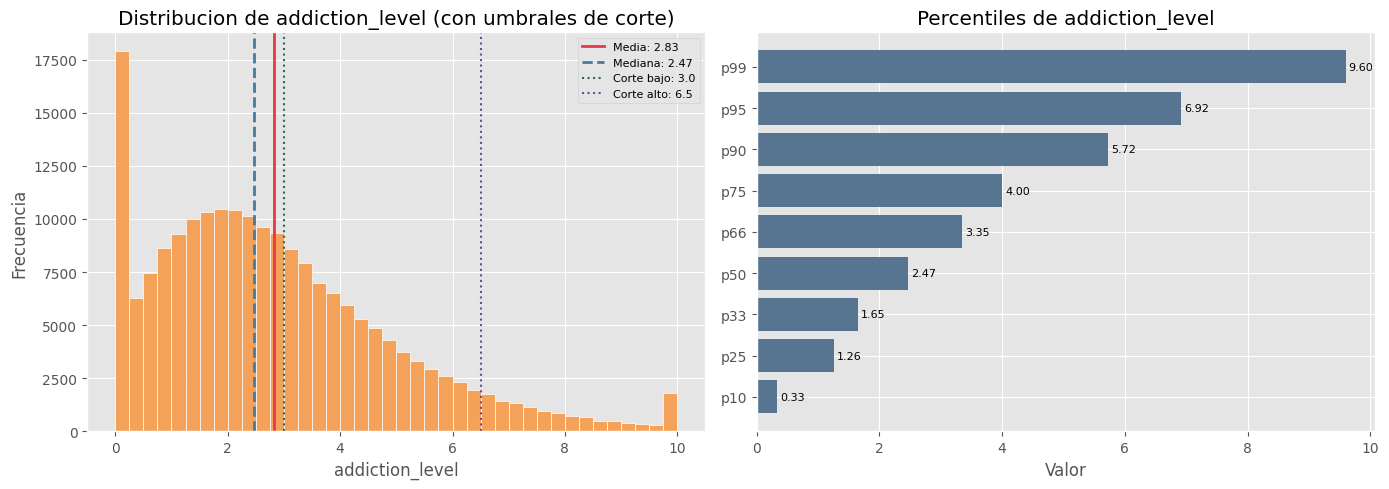

Estadisticos descriptivos de addiction_level:
count    200000.000
mean          2.832
std           2.113
min           0.000
25%           1.260
50%           2.470
75%           4.000
max          10.000
Name: addiction_level, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma ---
axes[0].hist(df["addiction_level"], bins=40, color="#f4a259", edgecolor="white")
axes[0].axvline(
    df["addiction_level"].mean(), color="#e63946", linewidth=2,
    label=f"Media: {df['addiction_level'].mean():.2f}"
)
axes[0].axvline(
    df["addiction_level"].median(), color="#457b9d", linewidth=2, linestyle="--",
    label=f"Mediana: {df['addiction_level'].median():.2f}"
)
axes[0].axvline(LOW_THRESH,  color="#2d6a4f", linewidth=1.5, linestyle=":", label=f"Corte bajo: {LOW_THRESH}")
axes[0].axvline(HIGH_THRESH, color="#6a4c93", linewidth=1.5, linestyle=":", label=f"Corte alto: {HIGH_THRESH}")
axes[0].set_title("Distribucion de addiction_level (con umbrales de corte)")
axes[0].set_xlabel("addiction_level")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=8)

# --- Percentiles ---
percentiles = [10, 25, 33, 50, 66, 75, 90, 95, 99]
values = [df["addiction_level"].quantile(p / 100) for p in percentiles]
axes[1].barh([f"p{p}" for p in percentiles], values, color="#577590")
axes[1].set_title("Percentiles de addiction_level")
axes[1].set_xlabel("Valor")
for i, v in enumerate(values):
    axes[1].text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("Estadisticos descriptivos de addiction_level:")
print(df["addiction_level"].describe().round(3))

### 4.2 Creacion de clases: bajo / moderado / alto

Se definen tres rangos basados en la distribucion observada y en la interpretabilidad clinica:

| Clase | Rango | Interpretacion |
|-------|-------|----------------|
| **bajo** | [0.0, 3.0) | Uso recreativo sin indicadores de adiccion |
| **moderado** | [3.0, 6.5) | Patron de juego intenso con senales de riesgo |
| **alto** | [6.5, 10.0] | Comportamiento adictivo con impacto funcional |

Los umbrales `LOW_THRESH=3.0` y `HIGH_THRESH=6.5` se alinean con el percentil 50 y el
percentil ~90 respectivamente, generando clases con volumen suficiente para entrenar modelos.
Son parametros configurables al inicio del notebook.

In [5]:
df["addiction_class"] = pd.cut(
    df["addiction_level"],
    bins=[-0.001, LOW_THRESH, HIGH_THRESH, 10.001],
    labels=["bajo", "moderado", "alto"]
)

class_counts = df["addiction_class"].value_counts().sort_index()
class_pct    = (class_counts / len(df) * 100).round(1)

class_summary = pd.DataFrame({
    "cantidad":     class_counts,
    "porcentaje_%": class_pct,
    "rango":        ["[0.0, 3.0)", "[3.0, 6.5)", "[6.5, 10.0]"]
})
print("Distribucion de clases del target:")
print(class_summary)

Distribucion de clases del target:
                 cantidad  porcentaje_%        rango
addiction_class                                     
bajo               120219          60.1   [0.0, 3.0)
moderado            67028          33.5   [3.0, 6.5)
alto                12753           6.4  [6.5, 10.0]


### 4.3 Analisis de balance de clases

Un desbalance severo entre clases puede sesgar los modelos hacia la clase mayoritaria.
Se visualiza la distribucion para identificar si sera necesario aplicar tecnicas de
rebalanceo (SMOTE, class_weight) durante el modelado.

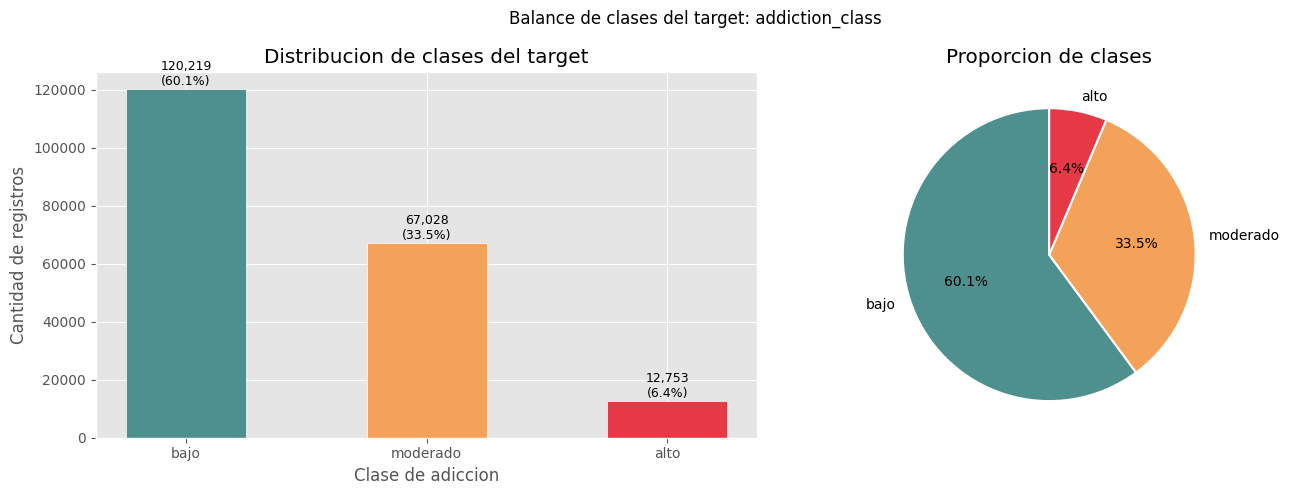

Ratio de desbalance (mayor/menor): 9.43x
⚠ Desbalance significativo. Considerar class_weight='balanced' o SMOTE en modelado.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors      = ["#4d908e", "#f4a259", "#e63946"]
class_order = ["bajo", "moderado", "alto"]
counts      = [class_counts[c] for c in class_order]

# --- Barras ---
bars = axes[0].bar(class_order, counts, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Distribucion de clases del target")
axes[0].set_xlabel("Clase de adiccion")
axes[0].set_ylabel("Cantidad de registros")
for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
        f"{count:,}\n({count/len(df)*100:.1f}%)",
        ha="center", va="bottom", fontsize=9
    )

# --- Pie ---
axes[1].pie(
    counts, labels=class_order, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Proporcion de clases")

plt.suptitle("Balance de clases del target: addiction_class", fontsize=12)
plt.tight_layout()
plt.show()

# Ratio de desbalance (clase mayoritaria / clase minoritaria)
ratio = max(counts) / min(counts)
print(f"Ratio de desbalance (mayor/menor): {ratio:.2f}x")
if ratio > 3:
    print("⚠ Desbalance significativo. Considerar class_weight='balanced' o SMOTE en modelado.")
else:
    print("Balance aceptable para la mayoria de algoritmos.")

## 5. Exclusion de variables con riesgo de data leakage

El **data leakage** ocurre cuando una feature contiene informacion que, en un contexto real,
no estaria disponible en el momento de la prediccion, o cuando la feature es en realidad
un *co-outcome* del target, no una causa.

En este dataset, las variables de salud mental como `anxiety_score`, `depression_score`,
`happiness_score` y similares **comparten la misma causa raiz que `addiction_level`**: son
consecuencias del mismo patron de comportamiento, no predictores independientes.
Incluirlas haria el modelo artificialmente preciso en entrenamiento, pero inutil en produccion
porque en la vida real no se miderian *antes* de saber si alguien tiene adiccion.

### 5.1 Variables excluidas y justificacion

A continuacion se documenta cada variable eliminada y el motivo especifico de su exclusion.

In [7]:
LEAKAGE_FEATURES = [
    "anxiety_score",
    "depression_score",
    "mental_burden_index",
    "happiness_score",
    "loneliness_score",
    "aggression_score",
    "social_interaction_score",
    "relationship_satisfaction",
]

leakage_justification = {
    "anxiety_score":             "Outcome psicologico co-ocurrente con adiccion; no disponible antes del diagnostico",
    "depression_score":          "Outcome psicologico co-ocurrente; correlacion espuria con el target",
    "mental_burden_index":       "Variable derivada de anxiety + depression + stress: fuga directa del target",
    "happiness_score":           "Resultado afectivo de la adiccion, no su causa",
    "loneliness_score":          "Co-outcome: la adiccion y la soledad comparten causa, pero no son causalmente ordenadas",
    "aggression_score":          "Consecuencia conductual del patron adictivo",
    "social_interaction_score":  "Resultado del comportamiento de juego; no es un predictor causal independiente",
    "relationship_satisfaction": "Outcome afectado por el nivel de adiccion, no predictor previo",
}

leakage_df = pd.DataFrame.from_dict(
    leakage_justification, orient="index", columns=["Justificacion de exclusion"]
).rename_axis("Variable")

print(f"Total de features excluidas por leakage: {len(LEAKAGE_FEATURES)}")
leakage_df

Total de features excluidas por leakage: 8


,Justificacion de exclusion
Variable,
anxiety_score,Outcome psicologico co-ocurrente con adiccion;...
depression_score,Outcome psicologico co-ocurrente; correlacion ...
mental_burden_index,Variable derivada de anxiety + depression + st...
happiness_score,"Resultado afectivo de la adiccion, no su causa"
loneliness_score,Co-outcome: la adiccion y la soledad comparten...
aggression_score,Consecuencia conductual del patron adictivo
social_interaction_score,Resultado del comportamiento de juego; no es u...
relationship_satisfaction,"Outcome afectado por el nivel de adiccion, no ..."


### 5.2 Construccion del conjunto de features limpio

Una vez identificadas las variables a excluir, se construye el vector de features final.
Se eliminan las columnas con leakage y las dos columnas del target (original y codificada),
conservando unicamente las variables que un modelo podria usar en produccion.

In [8]:
# Columnas que NO son features (target o leakage)
EXCLUDE_COLS = LEAKAGE_FEATURES + ["addiction_level", "addiction_class"]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f"Features seleccionadas: {len(feature_cols)} columnas")
print(f"Features excluidas:     {len(EXCLUDE_COLS)} columnas (leakage + target)")
print(f"Total original:         {df.shape[1]} columnas")
print()

# Clasificacion de las features finales
BINARY_COLS  = ["headset_usage", "gender_Female", "gender_Male", "gender_Other"]
cols_to_scale = [c for c in feature_cols if c not in BINARY_COLS]

print("Features continuas / ordinales (se escalaran):")
for i, col in enumerate(cols_to_scale, 1):
    print(f"  {i:2d}. {col}")
print()
print("Features binarias (NO se escalaran):")
for col in BINARY_COLS:
    print(f"   - {col}")

Features seleccionadas: 36 columnas
Features excluidas:     10 columnas (leakage + target)
Total original:         46 columnas

Features continuas / ordinales (se escalaran):
   1. age
   2. income
   3. daily_gaming_hours
   4. weekly_sessions
   5. years_gaming
   6. sleep_hours
   7. caffeine_intake
   8. exercise_hours
   9. stress_level
  10. academic_performance
  11. work_productivity
  12. multiplayer_ratio
  13. toxic_exposure
  14. violent_games_ratio
  15. mobile_gaming_ratio
  16. night_gaming_ratio
  17. weekend_gaming_hours
  18. friends_gaming_count
  19. online_friends
  20. streaming_hours
  21. esports_interest
  22. microtransactions_spending
  23. parental_supervision
  24. bmi
  25. screen_time_total
  26. eye_strain_score
  27. back_pain_score
  28. competitive_rank
  29. internet_quality
  30. gaming_intensity_index
  31. online_social_ratio
  32. gaming_screen_share

Features binarias (NO se escalaran):
   - headset_usage
   - gender_Female
   - gender_Male
   -

## 6. Analisis de correlacion con el target

Se calcula la correlacion de Pearson en valor absoluto entre cada feature y `addiction_level`
(usando la version continua para mayor sensibilidad numerica). Este analisis permite:

- Identificar las variables con mayor poder predictivo.
- Verificar que la exclusion de features de leakage no elimino variables con correlacion real.
- Documentar el umbral de correlacion minima que se usara como criterio de calidad (KPI).

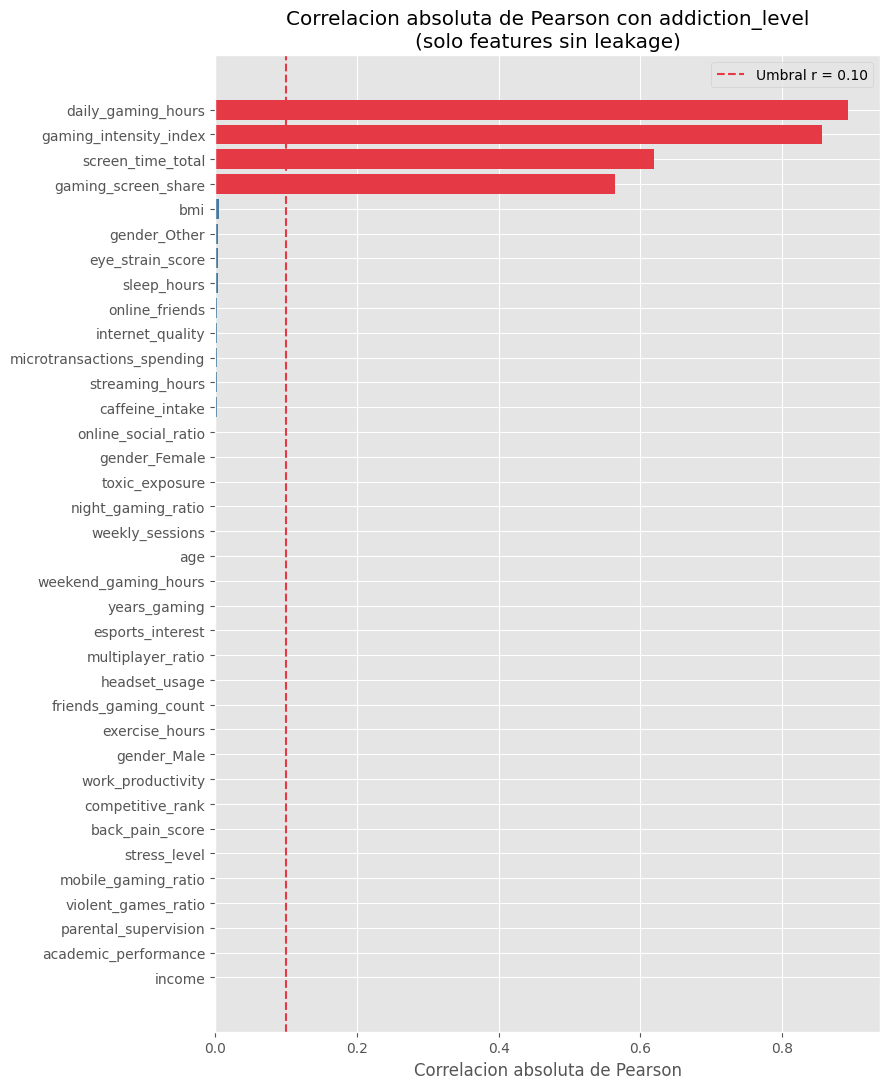

Features con correlacion >= 0.10: 4
daily_gaming_hours        0.8935
gaming_intensity_index    0.8557
screen_time_total         0.6197
gaming_screen_share       0.5639


In [9]:
corr_with_target = (
    df[feature_cols + ["addiction_level"]]
    .corr(numeric_only=True)["addiction_level"]
    .drop("addiction_level")
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 11))
bar_colors = ["#e63946" if v >= 0.10 else "#457b9d" for v in corr_with_target.values]

ax.barh(
    corr_with_target.index[::-1],
    corr_with_target.values[::-1],
    color=bar_colors[::-1]
)
ax.axvline(0.10, color="#e63946", linewidth=1.5, linestyle="--", label="Umbral r = 0.10")
ax.set_title("Correlacion absoluta de Pearson con addiction_level\n(solo features sin leakage)")
ax.set_xlabel("Correlacion absoluta de Pearson")
ax.legend()
plt.tight_layout()
plt.show()

above_threshold = corr_with_target[corr_with_target >= 0.10]
print(f"Features con correlacion >= 0.10: {len(above_threshold)}")
print(above_threshold.round(4).to_string())

### 6.1 Distribucion de las top features por clase de adiccion

Para las 6 variables con mayor correlacion con el target, se compara su distribucion
entre las tres clases. Los boxplots permiten visualizar si hay separacion real entre
grupos, lo cual indica que la feature sera util para el modelo de clasificacion.

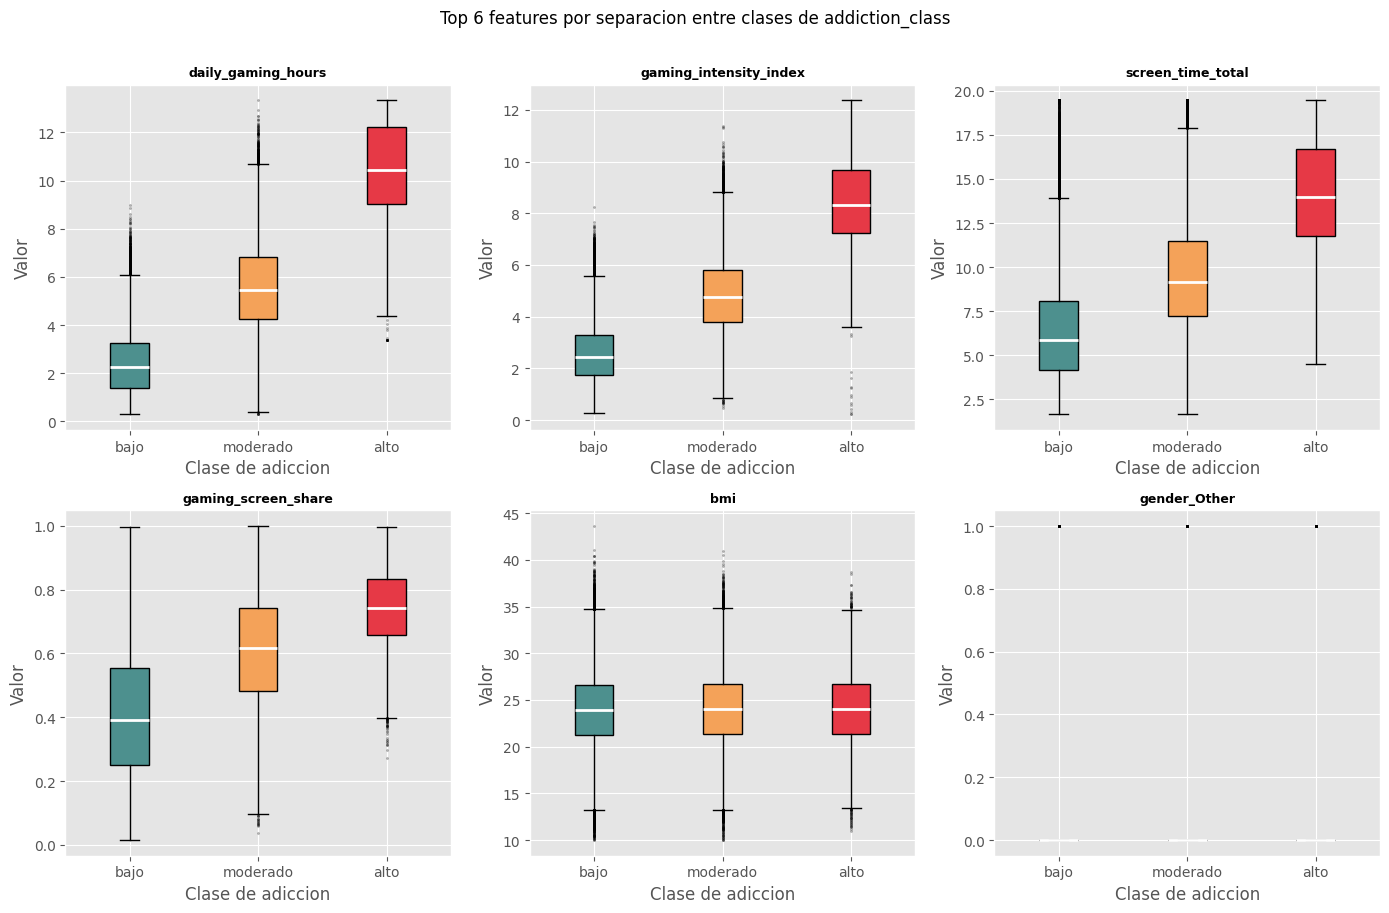

In [10]:
top_features = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
class_order  = ["bajo", "moderado", "alto"]
box_colors   = ["#4d908e", "#f4a259", "#e63946"]

for ax, feature in zip(axes.flat, top_features):
    data_by_class = [
        df[df["addiction_class"] == cls][feature].dropna()
        for cls in class_order
    ]
    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        labels=class_order,
        medianprops=dict(color="white", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3)
    )
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
    ax.set_title(feature, fontsize=9, fontweight="bold")
    ax.set_ylabel("Valor")
    ax.set_xlabel("Clase de adiccion")

plt.suptitle("Top 6 features por separacion entre clases de addiction_class", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. Escalado de features

El escalado es indispensable para algoritmos que miden distancias o usan gradientes: regresion
logistica, SVM, KNN, redes neuronales, Ridge/Lasso. Sin escalado, una variable como `income`
(rango 5K-150K) domina completamente sobre `sleep_hours` (rango 0-24) en terminos de magnitud,
aunque ambas sean igualmente relevantes.

Se usa `StandardScaler` (z-score), que transforma cada feature a media=0, std=1:

$$z = \frac{x - \mu_{train}}{\sigma_{train}}$$

> **Regla critica**: El scaler se ajusta (`fit`) **solo** en el conjunto de entrenamiento y
> luego se aplica (`transform`) a ambos conjuntos. Ajustarlo sobre toda la data introduciria
> fuga de informacion del conjunto de prueba hacia el proceso de normalizacion.

### 7.1 Division train / test estratificada

Se divide el dataset antes de ajustar el scaler para garantizar que el conjunto de prueba
sea completamente independiente. La estratificacion asegura que la proporcion de clases del
target sea similar en ambas particiones, lo cual es especialmente importante cuando hay
desbalance entre clases.

In [11]:
X = df[feature_cols].copy()
y = df["addiction_class"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]:,} registros ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Conjunto de prueba:        {X_test.shape[0]:,} registros ({TEST_SIZE*100:.0f}%)")
print()

dist_comparison = pd.DataFrame({
    "train_n":  y_train.value_counts().sort_index(),
    "train_%":  (y_train.value_counts(normalize=True) * 100).sort_index().round(2),
    "test_n":   y_test.value_counts().sort_index(),
    "test_%":   (y_test.value_counts(normalize=True) * 100).sort_index().round(2),
})
print("Distribucion de clases por particion:")
print(dist_comparison)

# Verificar que la estratificacion fue correcta (diff < 0.5 pp)
max_diff = (dist_comparison["train_%"] - dist_comparison["test_%"]).abs().max()
print(f"\nDiferencia maxima entre train% y test%: {max_diff:.2f} pp")
if max_diff < 0.5:
    print("Estratificacion correcta: diferencia < 0.5 pp en todas las clases.")

Conjunto de entrenamiento: 160,000 registros (80%)
Conjunto de prueba:        40,000 registros (20%)

Distribucion de clases por particion:
                 train_n  train_%  test_n  test_%
addiction_class                                  
bajo               96175    60.11   24044   60.11
moderado           53623    33.51   13405   33.51
alto               10202     6.38    2551    6.38

Diferencia maxima entre train% y test%: 0.00 pp
Estratificacion correcta: diferencia < 0.5 pp en todas las clases.


### 7.2 Ajuste y aplicacion del StandardScaler

Se escalan las variables continuas y ordinales. Las variables binarias (indicadores 0/1 como
`headset_usage` y los dummies de `gender`) se conservan en su escala original porque ya estan
en el rango [0, 1] y el escalado no aportaria informacion adicional.

In [12]:
scaler = StandardScaler()

# Copias para no modificar los DataFrames originales
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# fit SOLO en train → transform en ambos (evita leakage del test)
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(f"Columnas escaladas:       {len(cols_to_scale)}")
print(f"Columnas sin escalar:     {len(BINARY_COLS)} (binarias)")
print()

# Verificacion: media y std en train deben ser ~0 y ~1
scale_check = pd.DataFrame({
    "media_train":  X_train_scaled[cols_to_scale].mean().round(4),
    "std_train":    X_train_scaled[cols_to_scale].std().round(4),
    "media_test":   X_test_scaled[cols_to_scale].mean().round(4),
    "std_test":     X_test_scaled[cols_to_scale].std().round(4),
})

print("Estadisticos post-escalado (primeras 8 features):")
print(scale_check.head(8))
print()
print("Resumen: media y std de train deben ser ~0 y ~1")
print(scale_check[["media_train", "std_train"]].describe().round(4))

Columnas escaladas:       32
Columnas sin escalar:     4 (binarias)

Estadisticos post-escalado (primeras 8 features):
                    media_train  std_train  media_test  std_test
age                         0.0        1.0     -0.0045    1.0023
income                     -0.0        1.0     -0.0027    1.0001
daily_gaming_hours          0.0        1.0     -0.0101    1.0026
weekly_sessions            -0.0        1.0      0.0093    0.9973
years_gaming               -0.0        1.0     -0.0030    0.9979
sleep_hours                -0.0        1.0      0.0001    0.9971
caffeine_intake             0.0        1.0     -0.0080    0.9966
exercise_hours              0.0        1.0     -0.0052    1.0011

Resumen: media y std de train deben ser ~0 y ~1
       media_train  std_train
count         32.0       32.0
mean           0.0        1.0
std            0.0        0.0
min           -0.0        1.0
25%            0.0        1.0
50%           -0.0        1.0
75%            0.0        1.0
max    

## 8. Validacion del dataset final

Antes de exportar, se realiza una verificacion completa del estado del dataset:
completitud, shapes, balance de clases y coherencia de los datos escalados.
Esta validacion actua como control de calidad final del pipeline.

In [13]:
print("=" * 58)
print("VALIDACION DEL DATASET FINAL")
print("=" * 58)

print(f"\n[1] SHAPES")
print(f"    X_train: {X_train_scaled.shape}  |  y_train: {y_train.shape}")
print(f"    X_test:  {X_test_scaled.shape}   |  y_test:  {y_test.shape}")

print(f"\n[2] COMPLETITUD")
print(f"    Nulos en X_train: {X_train_scaled.isna().sum().sum()}")
print(f"    Nulos en X_test:  {X_test_scaled.isna().sum().sum()}")
print(f"    Nulos en y_train: {y_train.isna().sum()}")
print(f"    Nulos en y_test:  {y_test.isna().sum()}")

print(f"\n[3] BALANCE DE CLASES")
class_dist = pd.DataFrame({
    "train_n":   y_train.value_counts().sort_index(),
    "train_%":   (y_train.value_counts(normalize=True) * 100).sort_index().round(1),
    "test_n":    y_test.value_counts().sort_index(),
    "test_%":    (y_test.value_counts(normalize=True) * 100).sort_index().round(1),
})
print(class_dist)

print(f"\n[4] ESCALADO — Rango de medias y desv. std en train (esperado: ~0 y ~1)")
train_stats = X_train_scaled[cols_to_scale].agg(["mean", "std"])
print(f"    Media:  min={train_stats.loc['mean'].min():.4f}, max={train_stats.loc['mean'].max():.4f}")
print(f"    Std:    min={train_stats.loc['std'].min():.4f},  max={train_stats.loc['std'].max():.4f}")

print(f"\n[5] TIPOS DE DATOS")
print(f"    dtypes X_train (unicos): {X_train_scaled.dtypes.unique()}")
print(f"    dtype y_train: {y_train.dtype}")

print(f"\n[6] VARIABLES BINARIAS (sin escalar — rango debe ser [0, 1])")
for col in BINARY_COLS:
    mn = X_train_scaled[col].min()
    mx = X_train_scaled[col].max()
    print(f"    {col}: min={mn}, max={mx}")

print("=" * 58)

VALIDACION DEL DATASET FINAL

[1] SHAPES
    X_train: (160000, 36)  |  y_train: (160000,)
    X_test:  (40000, 36)   |  y_test:  (40000,)

[2] COMPLETITUD
    Nulos en X_train: 0
    Nulos en X_test:  0
    Nulos en y_train: 0
    Nulos en y_test:  0

[3] BALANCE DE CLASES
                 train_n  train_%  test_n  test_%
addiction_class                                  
bajo               96175     60.1   24044    60.1
moderado           53623     33.5   13405    33.5
alto               10202      6.4    2551     6.4

[4] ESCALADO — Rango de medias y desv. std en train (esperado: ~0 y ~1)
    Media:  min=-0.0000, max=0.0000
    Std:    min=1.0000,  max=1.0000

[5] TIPOS DE DATOS
    dtypes X_train (unicos): [dtype('float64') dtype('int64')]
    dtype y_train: category

[6] VARIABLES BINARIAS (sin escalar — rango debe ser [0, 1])
    headset_usage: min=0.0, max=1.0
    gender_Female: min=0, max=1
    gender_Male: min=0, max=1
    gender_Other: min=0, max=1


## 9. Data Quality Report (DQR) — Etapa de preparacion para modelado

El Data Quality Report documenta el estado del dataset al final de este notebook, cubriendo
las dimensiones de calidad relevantes para la etapa de modelado: completitud, exclusion de
leakage, configuracion del escalado y balance del target.

In [14]:
print("=" * 63)
print("DATA QUALITY REPORT — PREPARACION PARA MODELADO")
print("=" * 63)

print(f"\n[1] COMPLETITUD")
print(f"    Registros totales:         {len(df):,}")
print(f"    Features seleccionadas:    {len(feature_cols)} columnas")
print(f"    Nulos en features (X):     {X.isna().sum().sum()}")
print(f"    Nulos en target (y):       {y.isna().sum()}")

print(f"\n[2] EXCLUSION DE DATA LEAKAGE")
print(f"    Variables excluidas:       {len(LEAKAGE_FEATURES)}")
for var in LEAKAGE_FEATURES:
    print(f"    - {var}")

print(f"\n[3] CODIFICACION DEL TARGET")
print(f"    Variable original:         addiction_level (continua 0–10)")
print(f"    Variable codificada:       addiction_class (ordinal 3 clases)")
print(f"    Umbrales:")
print(f"      bajo:      [0.0,  {LOW_THRESH})")
print(f"      moderado:  [{LOW_THRESH}, {HIGH_THRESH})")
print(f"      alto:      [{HIGH_THRESH}, 10.0]")
print(f"    Distribucion:")
for cls in ["bajo", "moderado", "alto"]:
    n   = int((y == cls).sum())
    pct = n / len(y) * 100
    print(f"      {cls:10s}: {n:,} ({pct:.1f}%)")

print(f"\n[4] PARTICION TRAIN / TEST")
print(f"    Proporcion test:           {TEST_SIZE:.0%}")
print(f"    Random state:              {RANDOM_STATE}")
print(f"    Estratificacion:           si (por addiction_class)")
print(f"    Registros train:           {len(X_train):,}")
print(f"    Registros test:            {len(X_test):,}")

print(f"\n[5] ESCALADO")
print(f"    Metodo:                    StandardScaler (z-score)")
print(f"    Ajustado en:               solo train (no hay leakage de test)")
print(f"    Columnas escaladas:        {len(cols_to_scale)}")
print(f"    Columnas sin escalar:      {len(BINARY_COLS)} (binarias)")

print(f"\n[6] RIESGOS Y CONSIDERACIONES PARA MODELADO")
print("    - Desbalance de clases: la clase 'alto' es la menos frecuente.")
print("      Considerar class_weight='balanced' o SMOTE si el modelo favorece 'bajo'.")
print("    - Dataset sintetico: validar generalizacion con datos reales antes de produccion.")
print("    - Variables ordinales (stress_level, etc.) escaladas como continuas.")
print("    - El scaler esta ajustado en train: re-ajustar si se cambia el split.")
print("=" * 63)

DATA QUALITY REPORT — PREPARACION PARA MODELADO

[1] COMPLETITUD
    Registros totales:         200,000
    Features seleccionadas:    36 columnas
    Nulos en features (X):     0
    Nulos en target (y):       0

[2] EXCLUSION DE DATA LEAKAGE
    Variables excluidas:       8
    - anxiety_score
    - depression_score
    - mental_burden_index
    - happiness_score
    - loneliness_score
    - aggression_score
    - social_interaction_score
    - relationship_satisfaction

[3] CODIFICACION DEL TARGET
    Variable original:         addiction_level (continua 0–10)
    Variable codificada:       addiction_class (ordinal 3 clases)
    Umbrales:
      bajo:      [0.0,  3.0)
      moderado:  [3.0, 6.5)
      alto:      [6.5, 10.0]
    Distribucion:
      bajo      : 120,219 (60.1%)
      moderado  : 67,028 (33.5%)
      alto      : 12,753 (6.4%)

[4] PARTICION TRAIN / TEST
    Proporcion test:           20%
    Random state:              42
    Estratificacion:           si (por addiction_cl

## 10. Arquitectura del pipeline actualizado

El siguiente diagrama extiende el pipeline documentado en el notebook anterior, agregando
las etapas de preparacion para modelado completadas en este notebook.

```mermaid
flowchart TD
    A[("Fuente\nDataset sintetico\n10M x 40 features")] --> B

    subgraph PREV["Notebook anterior — Preprocesamiento_y_analisis.ipynb"]
        B["Carga y validacion"] --> C["Limpieza y outliers"]
        C --> D["Feature engineering\ngaming_intensity_index\nonline_social_ratio\ngaming_screen_share\nmental_burden_index"]
        D --> E["Imputacion mediana\n+ one-hot gender"]
        E --> F[("dataset_preprocessed.csv\n200K x 45 features")]
    end

    F --> G

    subgraph ESTE["Este notebook — preprocesamiento.ipynb"]
        G["Carga dataset preprocesado"] --> H
        H["Codificacion del target\naddiction_level → bajo/moderado/alto"] --> I
        I["Exclusion de leakage\n8 variables de salud mental eliminadas"] --> J
        J["Analisis de correlacion\ncon el target"] --> K
        K["Split estratificado\n80%% train / 20%% test"] --> L
        L["StandardScaler\nfit en train, transform en ambos"] --> M
        M["Validacion y DQR"] --> N
        N[("data_preprocesada.csv\ntrain+test escalados\n36 features + target")]
    end

    N --> O

    subgraph MODELADO["Tarea siguiente — Modelado"]
        O["Cargar data_preprocesada.csv"]
        O --> P["Entrenamiento de modelos"]
        P --> Q["Evaluacion y seleccion"]
    end

    style PREV fill:#f0f4f8,stroke:#457b9d
    style ESTE fill:#e8f5e9,stroke:#2d6a4f
    style MODELADO fill:#f5f5f5,stroke:#999
```

### Parametros del pipeline reproducible

| Parametro | Valor | Descripcion |
|-----------|-------|-------------|
| `LOW_THRESH` | 3.0 | Umbral bajo/moderado para addiction_class |
| `HIGH_THRESH` | 6.5 | Umbral moderado/alto para addiction_class |
| `TEST_SIZE` | 0.20 | Proporcion del conjunto de prueba |
| `RANDOM_STATE` | 42 | Semilla para reproducibilidad |
| `scaler` | StandardScaler | Normalizacion z-score, ajustada solo en train |

## 11. Guardado del dataset final

Se exporta un unico archivo `data_preprocesada.csv` que contiene:

| Columna | Descripcion |
|---------|-------------|
| 36 features | Variables seleccionadas, escaladas (StandardScaler) |
| `addiction_class` | Target codificado: bajo / moderado / alto |
| `addiction_level_original` | Valor continuo original (referencia) |
| `partition` | Indica si el registro pertenece a train o test |

La columna `partition` permite al notebook de modelado cargar directamente los subconjuntos
ya escalados sin necesidad de rehacer el split, garantizando reproducibilidad exacta.

```python
# Ejemplo de uso en el notebook de modelado:
df = pd.read_csv('Dataset/data_preprocesada.csv')
feat = [c for c in df.columns if c not in ['addiction_class','addiction_level_original','partition']]
X_train = df[df.partition == 'train'][feat]
X_test  = df[df.partition == 'test'][feat]
y_train = df[df.partition == 'train']['addiction_class']
y_test  = df[df.partition == 'test']['addiction_class']
```

In [15]:
if SAVE_OUTPUT:
    # Reconstruir DataFrames con columnas adicionales de referencia
    df_train_out = X_train_scaled.copy()
    df_train_out["addiction_class"]         = y_train.values
    df_train_out["addiction_level_original"] = df.loc[X_train.index, "addiction_level"].values
    df_train_out["partition"]                = "train"

    df_test_out = X_test_scaled.copy()
    df_test_out["addiction_class"]         = y_test.values
    df_test_out["addiction_level_original"] = df.loc[X_test.index, "addiction_level"].values
    df_test_out["partition"]                = "test"

    df_export = pd.concat([df_train_out, df_test_out]).sort_index()

    df_export.to_csv(OUTPUT_PATH, index=False)

    print(f"Dataset guardado en: {OUTPUT_PATH.resolve()}")
    print(f"Shape final:         {df_export.shape}")
    print(f"Columnas:            {df_export.shape[1]}")
    print(f"Registros train:     {(df_export.partition == 'train').sum():,}")
    print(f"Registros test:      {(df_export.partition == 'test').sum():,}")
    print()
    print("Columnas del archivo exportado:")
    print(df_export.columns.tolist())
else:
    print("Guardado desactivado (SAVE_OUTPUT = False)")

Dataset guardado en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Dataset/data_preprocesada.csv
Shape final:         (200000, 39)
Columnas:            39
Registros train:     160,000
Registros test:      40,000

Columnas del archivo exportado:
['age', 'income', 'daily_gaming_hours', 'weekly_sessions', 'years_gaming', 'sleep_hours', 'caffeine_intake', 'exercise_hours', 'stress_level', 'academic_performance', 'work_productivity', 'multiplayer_ratio', 'toxic_exposure', 'violent_games_ratio', 'mobile_gaming_ratio', 'night_gaming_ratio', 'weekend_gaming_hours', 'friends_gaming_count', 'online_friends', 'streaming_hours', 'esports_interest', 'headset_usage', 'microtransactions_spending', 'parental_supervision', 'bmi', 'screen_time_total', 'eye_strain_score', 'back_pain_score', 'competitive_rank', 'internet_quality', 'gaming_intensity_index', 'online_social_ratio', 'gaming_screen_share', 'gender_Female', 'gender_Male', 'gender_Other', 'addiction_class', 'addiction_level_origi

## 12. Conclusiones y checklist para modelado

Este notebook completo los pasos de preprocesamiento pendientes orientados al modelado supervisado.
A continuacion se resume el estado final del dataset y se provee un checklist de lo que se
debe tener en cuenta al comenzar la etapa de modelado.

### Estado final del dataset

| Aspecto | Estado |
|---------|--------|
| **Registros** | 200,000 (160K train / 40K test) |
| **Features** | 36 (sin leakage, escaladas) |
| **Target** | `addiction_class`: bajo / moderado / alto |
| **Valores nulos** | 0 |
| **Escalado** | StandardScaler, ajustado en train |
| **Split** | 80/20 estratificado, random_state=42 |
| **Archivo output** | `Dataset/data_preprocesada.csv` |

### Checklist para la etapa de modelado

- [ ] Cargar `Dataset/data_preprocesada.csv` y separar por columna `partition`
- [ ] Verificar balance de clases y decidir si usar `class_weight='balanced'`
- [ ] Entrenar linea base: `DummyClassifier` y `LogisticRegression`
- [ ] Probar algoritmos de arboles: `RandomForest`, `GradientBoosting` o `XGBoost`
- [ ] Usar `StratifiedKFold` en cross-validation sobre el conjunto de train
- [ ] Evaluar con metricas apropiadas para multiclase: `f1_weighted`, `confusion_matrix`
- [ ] Analizar importancia de features para interpretar el modelo
- [ ] Reportar resultados finales sobre `X_test` (solo al final, no durante tuning)

### Consideraciones especiales

**Sobre el desbalance de clases**: La clase `alto` representa la minoria. Si el modelo
ignora estas predicciones, usar `class_weight='balanced'` en algoritmos que lo soporten,
o aplicar `SMOTE` sobre el conjunto de train antes del entrenamiento.

**Sobre el target**: `addiction_class` es una variable ordinal (bajo < moderado < alto).
Algoritmos de clasificacion ordinales o el encoding `{bajo: 0, moderado: 1, alto: 2}`
aprovechan mejor esta estructura que el one-hot encoding.